# 02 - Feature Extraction & Model Training

This notebook extracts **MFCC**, **Chroma** and **Mel-spectrogram** features
from each audio clip using `librosa`, then trains a small feed-forward deep
neural network (Keras) to classify the emotion.

The trained model, label encoder and feature scaler are exported to
`../app/model/` so the Flask web app can load them directly.

> Run `01_data_exploration.ipynb` first (or at least make sure
> `../data/RAVDESS/` is populated) before running this notebook end-to-end.


In [1]:
import fsspec
import zipfile
import io
import numpy as np
import pandas as pd
import soundfile as sf
import librosa

DATASET_URL = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"

# Lazy, seekable handle to the remote zip. Reads happen via HTTP range
# requests on demand, so the ~25GB archive is never downloaded/extracted
# to disk - only the bytes of the file currently being processed.
remote_zip_file = fsspec.open(DATASET_URL, mode="rb").open()
zf = zipfile.ZipFile(remote_zip_file)

wav_names = [n for n in zf.namelist() if n.lower().endswith(".wav")]
print(f"Found {len(wav_names)} audio files in the remote archive (nothing downloaded yet).")

EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

def parse_emotion_from_entry(entry_name):
    fname = entry_name.split("/")[-1]
    code = fname.split("-")[2]
    return EMOTION_MAP.get(code, "unknown")

df = pd.DataFrame({
    "zip_entry": wav_names,
    "emotion": [parse_emotion_from_entry(n) for n in wav_names],
})
df = df[df["emotion"] != "unknown"].reset_index(drop=True)
df.head()

Found 1440 audio files in the remote archive (nothing downloaded yet).


,zip_entry,emotion
0,Actor_01/03-01-01-01-01-01-01.wav,neutral
1,Actor_01/03-01-01-01-01-02-01.wav,neutral
2,Actor_01/03-01-01-01-02-01-01.wav,neutral
3,Actor_01/03-01-01-01-02-02-01.wav,neutral
4,Actor_01/03-01-02-01-01-01-01.wav,calm


In [2]:
def load_audio_from_zip(entry_name, sr_target=22050):
    with zf.open(entry_name) as f:
        audio_bytes = f.read()
    y, sr = sf.read(io.BytesIO(audio_bytes))
    if sr != sr_target:
        y = librosa.resample(y.astype(float), orig_sr=sr, target_sr=sr_target)
        sr = sr_target
    return y, sr

## 1. Collect file paths + labels

In [3]:

EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

def parse_emotion_from_entry(entry_name):
    fname = entry_name.split("/")[-1]
    code = fname.split("-")[2]
    return EMOTION_MAP.get(code, "unknown")

df = pd.DataFrame({
    "zip_entry": wav_names,
    "emotion": [parse_emotion_from_entry(n) for n in wav_names],
})
df = df[df["emotion"] != "unknown"].reset_index(drop=True)
df.head()

,zip_entry,emotion
0,Actor_01/03-01-01-01-01-01-01.wav,neutral
1,Actor_01/03-01-01-01-01-02-01.wav,neutral
2,Actor_01/03-01-01-01-02-01-01.wav,neutral
3,Actor_01/03-01-01-01-02-02-01.wav,neutral
4,Actor_01/03-01-02-01-01-01-01.wav,calm


## 2. Feature extraction function

For each clip we compute:
- **MFCC** (40 coefficients) - captures the timbral/spectral envelope of the voice
- **Chroma STFT** (12 bins) - captures pitch-class energy, useful for tone/prosody
- **Mel spectrogram** (128 bands) - a perceptually-scaled frequency representation

Each is averaged over time (mean pooling), giving a fixed-length feature
vector per clip regardless of its duration - 180 features total
(40 + 12 + 128).


In [4]:
def extract_feature_from_zip(entry_name, mfcc=True, chroma=True, mel=True, sr_target=22050):
    X, sr = load_audio_from_zip(entry_name, sr_target=sr_target)
    result = np.array([])
    stft = np.abs(librosa.stft(X))
    if mfcc:
        mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sr, n_mfcc=40).T, axis=0)
        result = np.hstack((result, mfccs))
    if chroma:
        chroma_f = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
        result = np.hstack((result, chroma_f))
    if mel:
        mel_f = np.mean(librosa.feature.melspectrogram(y=X, sr=sr).T, axis=0)
        result = np.hstack((result, mel_f))
    return result

## 3. Build the feature matrix

This step loops over every file and can take a few minutes on the full
RAVDESS dataset (~1,440 clips). Feel free to start with a subset
(`df.sample(200)`) while iterating on the model architecture.


In [5]:
X, y = [], []

for _, row in df.iterrows():
    try:
        feat = extract_feature_from_zip(row["zip_entry"])
        X.append(feat)
        y.append(row["emotion"])
    except Exception as e:
        print(f"Skipping {row['zip_entry']}: {e}")

X = np.array(X)
y = np.array(y)
print("Feature matrix shape:", X.shape)

c:\Users\user\Desktop\speech-emotion-recognition\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1
  warnings.warn(


Skipping Actor_01/03-01-02-01-01-02-01.wav: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)
Skipping Actor_01/03-01-08-01-02-02-01.wav: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)
Skipping Actor_05/03-01-02-01-02-02-05.wav: Unable to allocate 3.11 GiB for an array with shape (203403, 1025, 1) and data type complex128
Skipping Actor_20/03-01-03-01-02-01-20.wav: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)
Skipping Actor_20/03-01-06-01-01-02-20.wav: Unable to allocate 3.20 GiB for an array with shape (209809, 1025, 1) and data type complex128
Feature matrix shape: (1435, 180)


## 4. Encode labels + scale features

In [6]:
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = keras.utils.to_categorical(y_encoded)

print("Classes:", list(label_encoder.classes_))


Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

feature_mean = X_train.mean(axis=0)
feature_std = X_train.std(axis=0) + 1e-8

X_train_scaled = (X_train - feature_mean) / feature_std
X_test_scaled = (X_test - feature_mean) / feature_std

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (1148, 180)  Test shape: (287, 180)


## 5. Build the model

A straightforward fully-connected network on top of the pooled MFCC/Chroma/Mel
features. This keeps training fast and is a strong baseline; a CNN or
LSTM over the raw time-series features is a natural next step (see the
**Ideas for improvement** section in the README).


In [9]:
num_classes = y_categorical.shape[1]

model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(num_classes, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        46,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,008 (343.78 KB)

 Trainable params: 88,008 (343.78 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/100
72/72 - 4s - 51ms/step - accuracy: 0.2378 - loss: 1.9753 - val_accuracy: 0.3449 - val_loss: 1.7944
Epoch 2/100
72/72 - 1s - 12ms/step - accuracy: 0.3702 - loss: 1.7065 - val_accuracy: 0.3937 - val_loss: 1.6310
Epoch 3/100
72/72 - 0s - 6ms/step - accuracy: 0.4399 - loss: 1.5224 - val_accuracy: 0.4181 - val_loss: 1.5203
Epoch 4/100
72/72 - 0s - 6ms/step - accuracy: 0.4634 - loss: 1.4312 - val_accuracy: 0.4669 - val_loss: 1.4613
Epoch 5/100
72/72 - 0s - 6ms/step - accuracy: 0.5174 - loss: 1.3093 - val_accuracy: 0.4355 - val_loss: 1.4277
Epoch 6/100
72/72 - 1s - 8ms/step - accuracy: 0.5436 - loss: 1.2253 - val_accuracy: 0.4843 - val_loss: 1.3503
Epoch 7/100
72/72 - 1s - 10ms/step - accuracy: 0.5723 - loss: 1.1450 - val_accuracy: 0.4739 - val_loss: 1.3423
Epoch 8/100
72/72 - 1s - 8ms/step - accuracy: 0.5932 - loss: 1.0798 - val_accuracy: 0.5261 - val_loss: 1.2291
Epoch 9/100
72/72 - 0s - 7ms/step - accuracy: 0.6385 - loss: 0.9856 - val_accuracy: 0.5296 - val_loss: 1.2697
Epoch 1

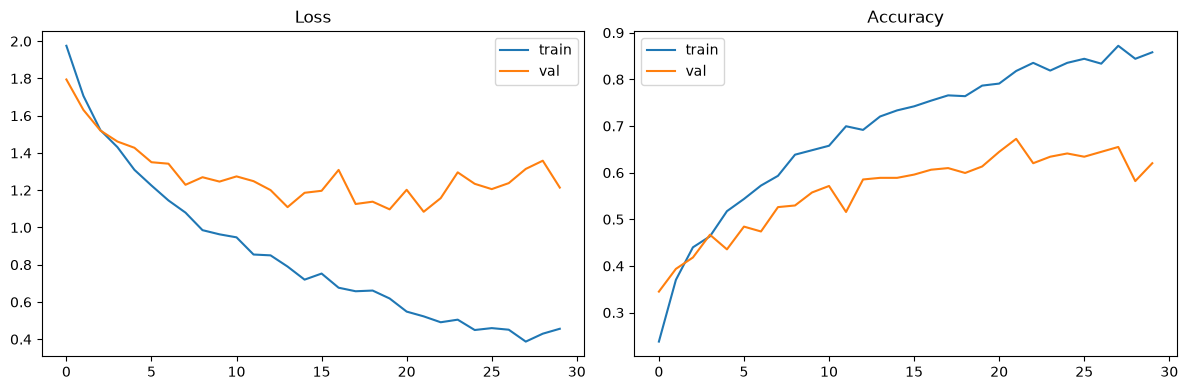

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluate

In [13]:
from sklearn.metrics import classification_report
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

y_pred = np.argmax(model.predict(X_test_scaled), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


Test accuracy: 0.672
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

       angry       0.88      0.77      0.82        39
        calm       0.60      0.79      0.68        38
     disgust       0.65      0.63      0.64        38
     fearful       0.60      0.82      0.69        38
       happy       0.70      0.61      0.65        38
     neutral       0.45      0.47      0.46        19
         sad       0.64      0.41      0.50        39
   surprised       0.83      0.79      0.81        38

    accuracy                           0.67       287
   macro avg       0.67      0.66      0.66       287
weighted avg       0.68      0.67      0.67       287



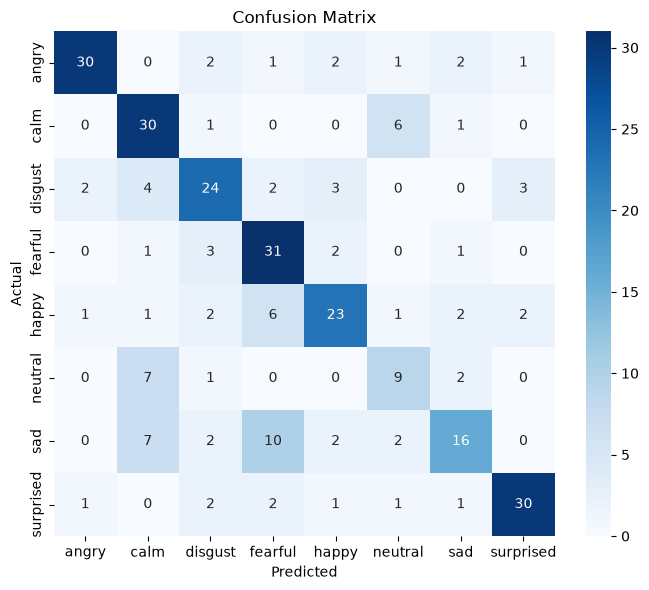

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. Export artifacts for the web app

Saves everything the Flask app in `../app/` needs to serve predictions:

- `emotion_model.h5` - trained Keras model
- `label_encoder.pkl` - maps predicted index back to an emotion label
- `scaler.pkl` - feature mean/std used to standardize inputs at inference time


In [18]:
import os
import pickle

# Directory for the exported model artifacts
MODEL_OUT_DIR = os.path.abspath(os.path.join("..", "app", "model"))
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

model.save(os.path.join(MODEL_OUT_DIR, "emotion_model.h5"))

with open(os.path.join(MODEL_OUT_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

with open(os.path.join(MODEL_OUT_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump({"mean": feature_mean, "std": feature_std}, f)

print("Saved model, label encoder and scaler to", MODEL_OUT_DIR)


Saved model, label encoder and scaler to c:\Users\user\Desktop\speech-emotion-recognition\app\model


## Next step

Start the web app:

```bash
cd ../app
pip install -r ../requirements.txt
python app.py
```

Then open `http://127.0.0.1:5000` and upload a clip (or use one of the
bundled samples) to see the model make a prediction live - handy for
walking someone through the project in an interview.
